## 3D Reconstruction Via Volumetric Reconstruction

In [63]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
import open3d as o3d
from mpl_toolkits.mplot3d import Axes3D
import os


# Camera Calibration 
## Method
### Zhang's Method for Camera Calibration

Zhang’s method, developed by Zhengyou Zhang, is an efficient technique for calibrating a camera using a flat calibration object, such as a checkerboard pattern. This method is popular due to its simplicity, accuracy, and the fact that it does not require complex 3D objects or specialized equipment. Instead, it relies on capturing multiple images of a planar pattern from various orientations, making it widely applicable in real-world scenarios.

\subsection*{1. Mathematical Model of the Camera}

In Zhang’s approach, the camera model is decomposed into intrinsic and extrinsic parameters:
- \textbf{Intrinsic Parameters} define the camera's internal characteristics:
  
  $$
  \mathbf{K} = \begin{bmatrix} f_x & s & c_x \\ 0 & f_y & c_y \\ 0 & 0 & 1 \end{bmatrix}
  $$

  where:
  - $f_x$ and $f_y$ are the focal lengths in pixels,
  - $(c_x, c_y)$ is the principal point, and
  - $s$ is the skew coefficient (often close to zero for most cameras).
  
- \textbf{Extrinsic Parameters} describe the rotation and translation between the camera and the world coordinate system:

  $$
  \mathbf{P} = \mathbf{K} [\mathbf{R} \,|\, \mathbf{t}]
  $$

  where $\mathbf{R}$ is the rotation matrix and $\mathbf{t}$ is the translation vector.

\subsection*{2. Homography-Based Initial Estimation}

For each view of the checkerboard, the 3D world coordinates $(X_w, Y_w, 0)$ reduce to 2D coordinates on the plane. The relationship between the world points $\mathbf{X}_w = (X_w, Y_w, 1)^T$ and the corresponding 2D image points $\mathbf{x} = (x, y, 1)^T$ is captured by a \textbf{homography matrix} $\mathbf{H}$ such that:

$$
\mathbf{x} = \mathbf{H} \mathbf{X}_w
$$

For each view, the homography $\mathbf{H}$ relates the planar world coordinates to the 2D image coordinates and can be expressed as:

$$
\mathbf{H} = \mathbf{K} [\mathbf{r}_1 \, \mathbf{r}_2 \, \mathbf{t}]
$$

where $\mathbf{r}_1$ and $\mathbf{r}_2$ are the first two columns of the rotation matrix $\mathbf{R}$. Given that $\mathbf{r}_1$ and $\mathbf{r}_2$ are orthogonal unit vectors, we derive the following constraints:

$$
\mathbf{h}_1^T \mathbf{K}^{-T} \mathbf{K}^{-1} \mathbf{h}_2 = 0
$$
$$
\mathbf{h}_1^T \mathbf{K}^{-T} \mathbf{K}^{-1} \mathbf{h}_1 = \mathbf{h}_2^T \mathbf{K}^{-T} \mathbf{K}^{-1} \mathbf{h}_2
$$

where $\mathbf{h}_1$ and $\mathbf{h}_2$ are the columns of $\mathbf{H}$. By accumulating these constraints across multiple views of the calibration pattern, we obtain a system of linear equations.

\subsection*{3. Estimating the Intrinsic Matrix $\mathbf{K}$}

With at least three views of the pattern, we form a matrix system:

$$
\mathbf{V} \mathbf{b} = 0
$$

where $\mathbf{V}$ is a matrix built from the constraints, and $\mathbf{b}$ is a vector representing elements of $\mathbf{K}^{-T} \mathbf{K}^{-1}$. Solving for $\mathbf{b}$ yields an estimate for the intrinsic matrix $\mathbf{K}$, from which the intrinsic parameters $f_x$, $f_y$, $s$, $c_x$, and $c_y$ can be extracted.

\subsection*{4. Determining Extrinsic Parameters}

Once $\mathbf{K}$ is estimated, each homography matrix $\mathbf{H}$ provides the extrinsic parameters $\mathbf{R}$ and $\mathbf{t}$ for that view as follows:

$$
\mathbf{r}_1 = \lambda \mathbf{K}^{-1} \mathbf{h}_1, \quad \mathbf{r}_2 = \lambda \mathbf{K}^{-1} \mathbf{h}_2, \quad \mathbf{t} = \lambda \mathbf{K}^{-1} \mathbf{h}_3
$$

where $\lambda$ is a scaling factor, and $\mathbf{h}_1, \mathbf{h}_2, \mathbf{h}_3$ are the columns of $\mathbf{H}$. The rotation matrix $\mathbf{R}$ is obtained by orthonormalizing $\mathbf{r}_1$ and $\mathbf{r}_2$.

## Advantages of using cheaker board pattern

1. High contrast between black and white squares allows for precise corner detection.
2. Well-defined square corners enable subpixel accuracy in locating key points.
3. Simple 2D planar structure reduces model complexity and simplifies homography calculations.
4. Easily available and reproducible, making calibration setup convenient.
5. Portable, allowing capture from multiple views to improve calibration robustness.





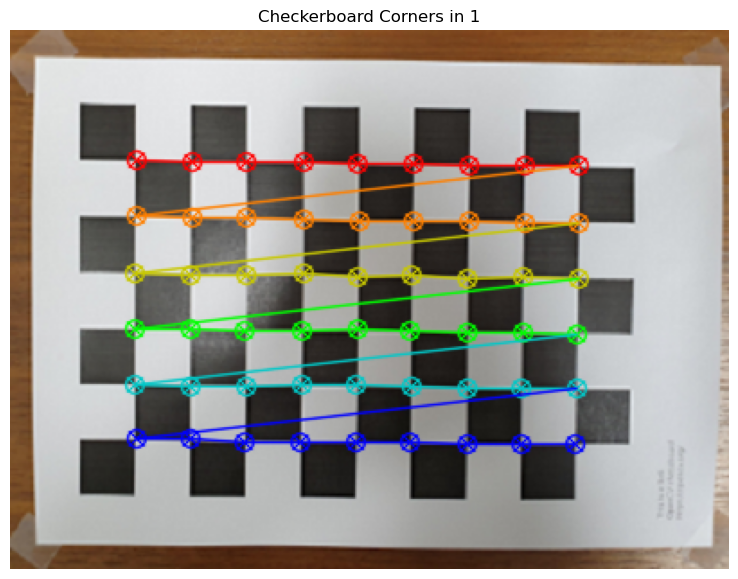

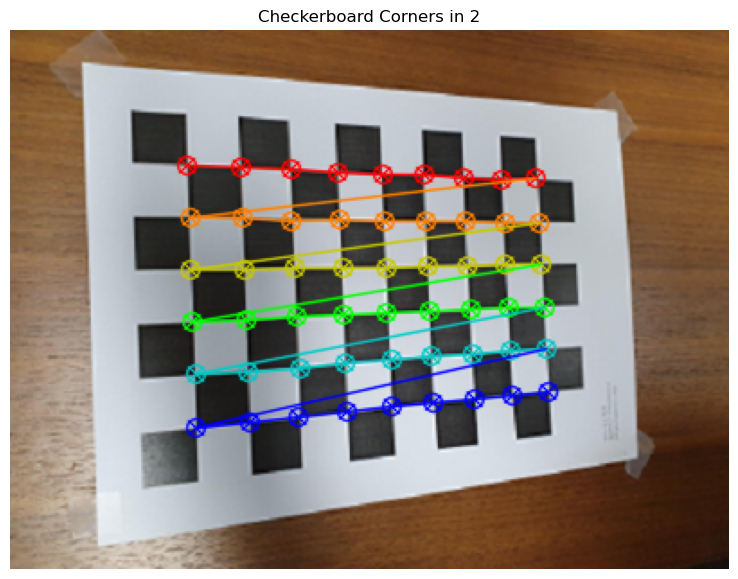

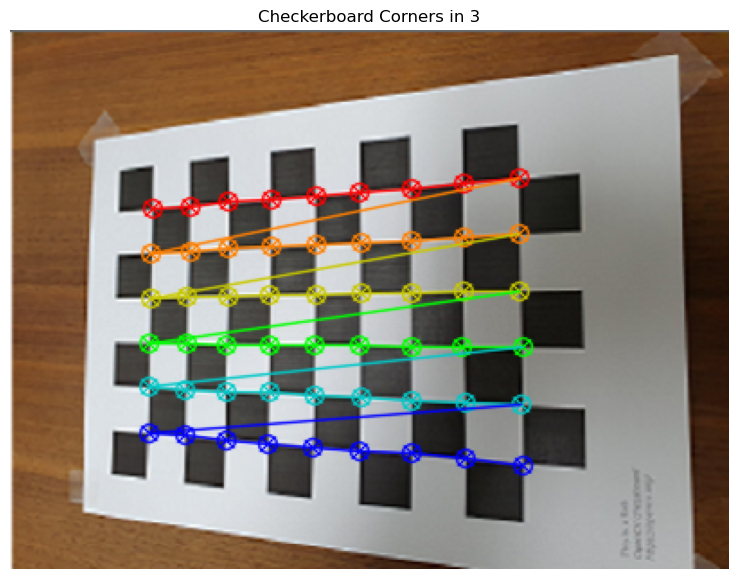

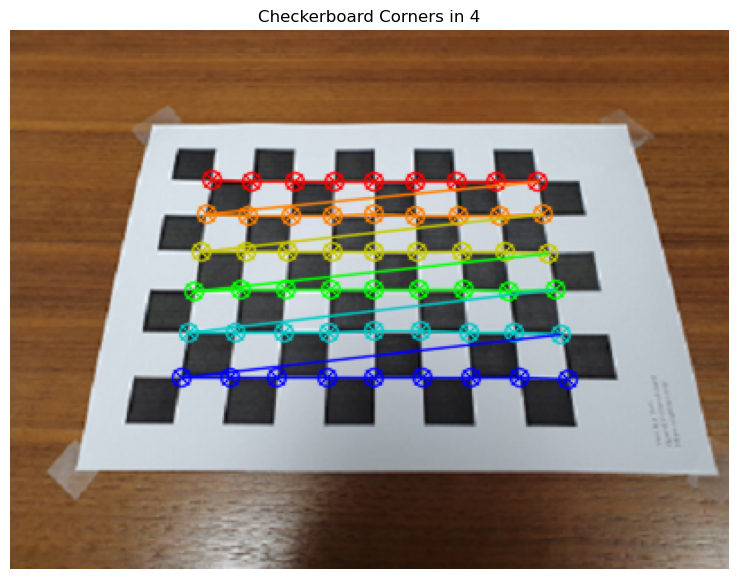

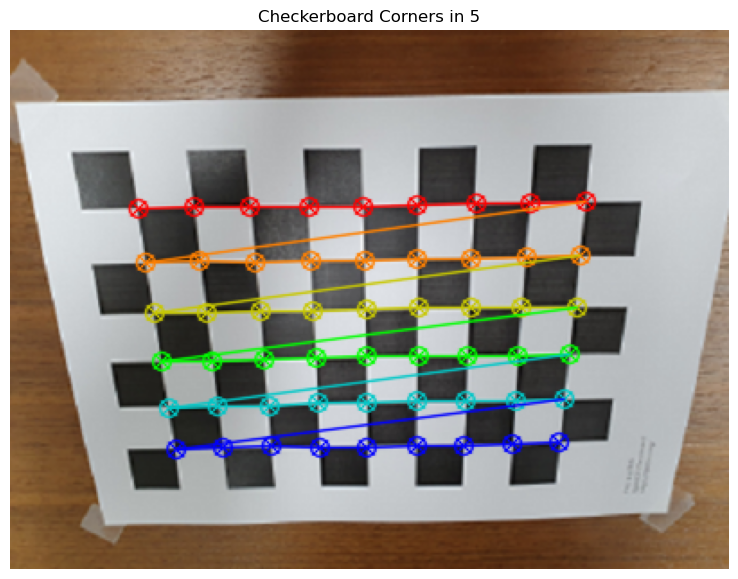

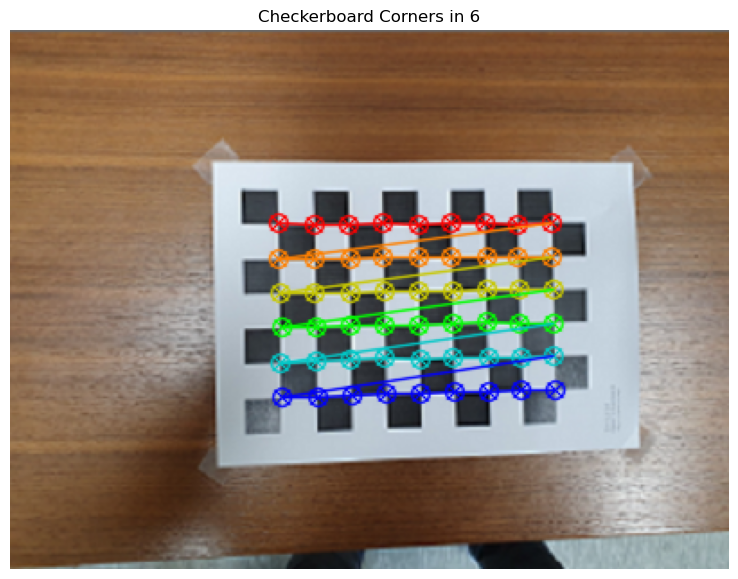

Camera Matrix (K):
 [[308.58097318   0.         199.37121186]
 [  0.         309.76212726 145.26129518]
 [  0.           0.           1.        ]]
Distortion Coefficients:
 [[ 3.59829894e-01 -2.46500588e+00  6.30268113e-04 -2.74961863e-03
   4.76691036e+00]]
New Undistorted Camera Matrix:
 [[322.4587426    0.         198.72069673]
 [  0.         312.81279052 145.45885585]
 [  0.           0.           1.        ]]


In [64]:
# Path to calibration images (change this to your directory where the chessboard images are stored)
calibration_dir_path = r'E:\BEEE\Final Year Project\FYP-2\Tasks\6. 3D recinstruction via disperity map\6) 3D reconstruction via disparity\cal\*.png'

# Fetch all image files that match the pattern (all .png files in the 'cal' directory)
calibration_images = glob.glob(calibration_dir_path)

# Initialize arrays for storing camera calibration parameters
K = np.array([], dtype=np.float32)  # Camera intrinsic matrix (will be calculated)
dist = np.array([], dtype=np.float32)  # Distortion coefficients (will be calculated)
K_undist = np.array([], dtype=np.float32)  # New undistorted camera matrix (will be calculated later)

# Termination criteria for refining corner detection to sub-pixel accuracy:
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 24, 0.001)

# Prepare a template of 3D object points corresponding to the chessboard pattern
objp = np.zeros((6 * 9, 3), np.float32)  # 6 rows and 9 columns of corners
objp[:, :2] = np.mgrid[0:9, 0:6].T.reshape(-1, 2)

# Lists to hold the 3D object points and their corresponding 2D image points
objpoints = []  # 3D points in the real world
imgpoints = []  # 2D points in the image
gray = None  # To store the grayscale image for size reference
i=0
# Iterate over each calibration image to find chessboard corners
for fname in calibration_images:
    
    i=i+1
    # Read each image from the file
    img = cv2.imread(fname)
    # Convert the image to grayscale (needed for corner detection)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = img.shape[:2]  # Get the image dimensions (height and width)

    # Find chessboard corners in the grayscale image
    ret, corners = cv2.findChessboardCorners(gray, (9, 6), None)

    # If corners are found, process them further
    if ret == True:
        # Append the known 3D object points (fixed)
        objpoints.append(objp)

        # Refine the corner positions to sub-pixel accuracy
        corners2 = cv2.cornerSubPix(gray, corners, (1, 1), (-1, -1), criteria)

        # Append the known 3D object points (fixed)
        objpoints.append(objp)
        # Append the refined 2D corner points
        imgpoints.append(corners2)

        # Draw and display the corners on the image
        img_with_corners = cv2.drawChessboardCorners(img, (9, 6), corners2, ret)

        # Convert the BGR image to RGB for displaying with matplotlib
        img_with_corners_rgb = cv2.cvtColor(img_with_corners, cv2.COLOR_BGR2RGB)
        # Append the refined 2D corner points
        imgpoints.append(corners2)
        plt.figure(figsize=(10, 7))
        plt.imshow(img_with_corners_rgb)
        plt.title(f"Checkerboard Corners in {i}")
        plt.axis('off')  # Hide the axis for better visualization
        plt.show()

# Ensure that corners were detected in at least one image before proceeding
if len(objpoints) > 0 and len(imgpoints) > 0:
    # Calibrate the camera
    ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

    # Print the calculated camera matrix and distortion coefficients
    print("Camera Matrix (K):\n", K)
    print("Distortion Coefficients:\n", dist)

    # Use the camera matrix and distortion coefficients to obtain an optimal new camera matrix
    K_undist, roi = cv2.getOptimalNewCameraMatrix(K, dist, (w, h), 1, (w, h))

    # Print the new undistorted camera matrix
    print("New Undistorted Camera Matrix:\n", K_undist)
else:
    print("No chessboard corners were found in any of the images.")


## Uncalibrated Image 

1. Capture images for calibration. Use a calibration pattern (like a checkerboard) and capture multiple images from different angles.

2. Detect calibration points. Use image processing to find the corners of the checkerboard pattern and record the pixel coordinates $(u, v)$.

3. Define world coordinates. Set the 3D world coordinates for the detected points in the checkerboard pattern as:
   $$
   (X, Y, Z) = (x \cdot d, y \cdot d, 0)
   $$
   where $d$ is the size of each square and $(x, y)$ are the indices.

4. Estimate distortion coefficients. Use a calibration algorithm (like Zhang's method) to estimate the camera's intrinsic parameters $\mathbf{K}$ and distortion coefficients $(k_1, k_2, p_1, p_2, k_3)$.

5. Undistort the images. For each image, apply the distortion model:
   $$
   x_u = x_d (1 + k_1 r^2 + k_2 r^4 + k_3 r^6) + (2 p_1 x_d y_d + p_2 (r^2 + 2 x_d^2))
   $$
   $$
   y_u = y_d (1 + k_1 r^2 + k_2 r^4 + k_3 r^6) + (p_1 (r^2 + 2 y_d^2) + 2 p_2 x_d y_d)
   $$

6. Re-estimate intrinsic parameters. Repeat the calibration process using the undistorted images to update the intrinsic matrix $\mathbf{K}'$ and distortion coefficients.

7. Formulate the new calibration matrix. The updated intrinsic camera matrix $\mathbf{K}'$ is:
   $$
   \mathbf{K}' = \begin{bmatrix} 
   f_x' & s' & c_x' \\ 
   0 & f_y' & c_y' \\ 
   0 & 0 & 1 
   \end{bmatrix}
   $$

8. Validate calibration. Compare reprojected points with original detected points and calculate the reprojection error.

9. Apply to future images. Use the updated intrinsic matrix $\mathbf{K}'$ and distortion coefficients for subsequent tasks.


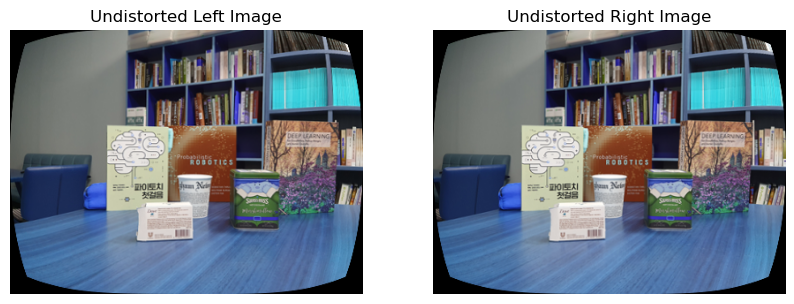

In [65]:
left_image = cv2.imread(''r'E:\BEEE\Final Year Project\FYP-2\Tasks\6. 3D recinstruction via disperity map\6) 3D reconstruction via disparity\left1.png')
right_image = cv2.imread(''r'E:\BEEE\Final Year Project\FYP-2\Tasks\6. 3D recinstruction via disperity map\6) 3D reconstruction via disparity\right1.png')
left_gray = cv2.cvtColor(left_image, cv2.COLOR_BGR2GRAY)
right_gray = cv2.cvtColor(right_image, cv2.COLOR_BGR2GRAY)

undistorted_left = np.array([])
undistorted_right = np.array([])
gray_undistorted_left = np.array([])
gray_undistorted_right = np.array([])

# Undistort the left image
undistorted_left = cv2.undistort(left_image, K, dist, None, K_undist)

# Undistort the right image
undistorted_right = cv2.undistort(right_image, K, dist, None, K_undist)

# Undistort the left gray image
gray_undistorted_left = cv2.undistort(left_gray, K, dist, None, K_undist)

# Undistort the right gray image
gray_undistorted_right = cv2.undistort(right_gray, K, dist, None, K_undist)

# Save or display the results
cv2.imwrite(''r'E:\BEEE\Final Year Project\FYP-2\Tasks\6. 3D recinstruction via disperity map\6) 3D reconstruction via disparity\results\undistrorted_left2.jpg', undistorted_left)
cv2.imwrite(''r'E:\BEEE\Final Year Project\FYP-2\Tasks\6. 3D recinstruction via disperity map\6) 3D reconstruction via disparity\results\undistrorted_right2.jpg', undistorted_right)


plt.figure(figsize=(10, 5))
plt.subplot(121), plt.imshow(undistorted_left)
plt.title('Undistorted Left Image'), plt.axis('off')
plt.subplot(122), plt.imshow(undistorted_right)
plt.title('Undistorted Right Image'), plt.axis('off')
plt.show()


## Dispirity Map
1. **Block Matching Concept**:
   - For each pixel in the left image $ I_L(x, y) $, a corresponding pixel in the right image $ I_R(x', y) $ is searched. The disparity $ d $ for a pixel is defined as:
   $$
   d = x_L - x_R
   $$
   - Here, $ x_L $ is the x-coordinate of the pixel in the left image, and $ x_R $ is the x-coordinate of the corresponding pixel in the right image.

2. **Cost Function**:
   - The cost function $ C(d) $ measures the similarity between blocks of pixels in the left and right images. Commonly used cost functions include:
     - **Sum of Absolute Differences (SAD)**:
     $$
     C(d) = \sum_{i=-\frac{W}{2}}^{\frac{W}{2}} \sum_{j=-\frac{W}{2}}^{\frac{W}{2}} \left| I_L(x + i, y + j) - I_R(x + i - d, y + j) \right|
     $$
     - **Sum of Squared Differences (SSD)**:
     $$
     C(d) = \sum_{i=-\frac{W}{2}}^{\frac{W}{2}} \sum_{j=-\frac{W}{2}}^{\frac{W}{2}} \left( I_L(x + i, y + j) - I_R(x + i - d, y + j) \right)^2
     $$
   - In both cases, $ W $ is the block size, and the summation runs over the pixels in the neighborhood defined by the block.

3. **Minimizing the Cost Function**:
   - The goal is to find the disparity $ d $ that minimizes the cost function for each pixel:
   $$
   D(x, y) = \arg \min_{d} C(d)
   $$
   - This means that for every pixel location $ (x, y) $ in the left image, the algorithm evaluates the cost for all possible disparity values within the specified range (up to `numDisparities`) and selects the disparity that yields the lowest cost.

4. **Disparity Map Construction**:
   - The computed disparity for each pixel forms a disparity map $ D $:
   $$
   D(x, y) = \text{disparity value at pixel } (x, y)
   $$
   - This map provides information about how far each point in the scene is from the cameras.

5. **Normalization for Visualization**:
   - To visualize the disparity map, it is often necessary to normalize the values to a range suitable for display (e.g., 0 to 255):
   $$
   D_{\text{normalized}}(x, y) = \frac{D(x, y) - D_{\text{min}}}{D_{\text{max}} - D_{\text{min}}} \cdot (b - a) + a
   $$
   - Here, $ D_{\text{min}} $ and $ D_{\text{max}} $ are the minimum and maximum disparity values in the computed disparity map, and $ a $ and $ b $ define the desired output range (typically $ a = 0 $ and $ b = 255 $).


In [66]:
def compute_disparity_map(imgL, imgR):
    """
    Function to compute disparity map from stereo images.
    :param imgL: Left stereo image
    :param imgR: Right stereo image
    :return: Disparity map
    """
    # Convert the images to grayscale if they are not already
    grayL = cv2.cvtColor(imgL, cv2.COLOR_BGR2GRAY)
    grayR = cv2.cvtColor(imgR, cv2.COLOR_BGR2GRAY)

    # Create StereoBM matcher
    stereo = cv2.StereoBM_create(numDisparities=16, blockSize=15)
    
    # Compute disparity map
    disparity_map = stereo.compute(grayL, grayR)
    
    # Normalize for visualization (optional)
    disparity_map = cv2.normalize(disparity_map, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    
    return disparity_map

## 3D Reconstruction
1. **Disparity and Depth Relation**:
   - The disparity $ d $ is inversely related to the depth $ Z $ of a point in the scene. The relationship is given by:
   $$
   Z = \frac{f \cdot B}{d}
   $$
   - Where:
     - $ Z $ is the depth of the point from the camera.
     - $ f $ is the focal length of the camera (in pixels).
     - $ B $ is the baseline, which is the distance between the two cameras.
     - $ d $ is the disparity value at pixel location $ (u, v) $.

2. **Intrinsic Parameters**:
   - The intrinsic camera matrix $ K $ is defined as:
   $$
   K = \begin{bmatrix}
   f_x & 0 & c_x \\
   0 & f_y & c_y \\
   0 & 0 & 1
   \end{bmatrix}
   $$
   - Where:
     - $ f_x $ and $ f_y $ are the focal lengths in pixels along the x and y axes.
     - $ c_x $ and $ c_y $ are the coordinates of the principal point (the optical center) in pixel coordinates.

3. **Calculating 3D Coordinates**:
   - For each pixel $ (u, v) $ in the disparity map, if the disparity $ d $ is valid (i.e., $ d > 0 $), the corresponding 3D coordinates $ (X, Y, Z) $ can be calculated as follows:
   - First, compute the depth $ Z $:
   $$
   Z = \frac{f_x \cdot B}{d}
   $$
   - Then, calculate the 3D coordinates $ X $ and $ Y $ using the relations:
   $$
   X = \frac{(u - c_x) \cdot Z}{f_x}
   $$
   $$
   Y = \frac{(v - c_y) \cdot Z}{f_y}
   $$

In [67]:
def reconstruct_3D(disparity_map, K, baseline):
    """
    Function to reconstruct 3D points from a disparity map.
    :param disparity_map: Disparity map of the image
    :param K: Intrinsic matrix
    :param baseline: Distance between the two cameras
    :return: 3D points
    """
    h, w = disparity_map.shape
    points_3D = []

    # Focal lengths and principal point
    fx = K[0, 0]  # Focal length in x
    fy = K[1, 1]  # Focal length in y
    cx = K[0, 2]  # Principal point x-coordinate
    cy = K[1, 2]  # Principal point y-coordinate

    for v in range(h):
        for u in range(w):
            d = disparity_map[v, u]
            if d > 0:  # Valid disparity
                # Calculate depth Z
                Z = (fx * baseline) / d

                # Calculate 3D coordinates (X, Y, Z)
                X = (u - cx) * Z / fx
                Y = (v - cy) * Z / fy

                points_3D.append((X, Y, Z))

    return np.array(points_3D)


In [68]:

def visualize_point_cloud(points_3D, imgL, disparity_map, K):
    """
    Function to visualize the 3D point cloud with color and save it to a file.

    :param points_3D: Array of 3D points
    :param imgL: Undistorted left image for color information
    :param disparity_map: Disparity map of the image
    :param K: Intrinsic matrix
    """
    # Extract intrinsic parameters
    fx, fy = K[0, 0], K[1, 1]  # Focal lengths
    cx, cy = K[0, 2], K[1, 2]  # Principal point coordinates

    # Create Open3D point cloud
    pcd = o3d.geometry.PointCloud()

    # Extract valid 3D points and their corresponding colors
    h, w = imgL.shape[:2]  # Get image dimensions
    valid_mask = (points_3D[:, 2] > 0)  # Only keep points with positive Z (depth)

    # Filter valid 3D points
    valid_points_3D = points_3D[valid_mask]

    # Compute pixel coordinates (u, v) for valid points
    u = ((valid_points_3D[:, 0] * fx) / valid_points_3D[:, 2] + cx).astype(int)
    v = ((valid_points_3D[:, 1] * fy) / valid_points_3D[:, 2] + cy).astype(int)

    # Ensure pixel coordinates are within bounds
    in_bounds_mask = (u >= 0) & (u < w) & (v >= 0) & (h > v)
    valid_points_3D = valid_points_3D[in_bounds_mask]
    u, v = u[in_bounds_mask], v[in_bounds_mask]

    # Get colors from the left image
    colors = imgL[v, u] / 255.0  # Normalize to [0, 1] range

    # Set points and colors to point cloud
    pcd.points = o3d.utility.Vector3dVector(valid_points_3D)
    pcd.colors = o3d.utility.Vector3dVector(colors)

    # Define save path
    save_path = r'E:\BEEE\Final Year Project\FYP-2\Tasks\6. 3D recinstruction via disperity map\6) 3D reconstruction via disparity\results'
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    # Visualize the point cloud
    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name="3D Point Cloud", width=1000, height=800)
    vis.add_geometry(pcd)

    # Set point size for better visibility
    opt = vis.get_render_option()
    opt.point_size = 3.0  # Increase point size for better visibility
    opt.background_color = np.array([1, 1, 1])  # Set background to white

    # Adjust camera parameters
    ctr = vis.get_view_control()
    ctr.set_front([0, 0, -1])  # Point camera towards the scene
    ctr.set_lookat([0, 0, 0])  # Center of the point cloud
    ctr.set_up([0, -1, 0])  # Set up vector for camera orientation
    ctr.set_zoom(0.5)  # Adjust zoom level (1.0 is the default, <1.0 zooms in, >1.0 zooms out)

    vis.run()

    # Save a screenshot of the visualizer
    screenshot_path = os.path.join(save_path, 'point_cloud_screenshot.png')
    vis.capture_screen_image(screenshot_path)
    print(f"Screenshot saved to {screenshot_path}")

    # Close the visualizer
    vis.destroy_window()

    # Save the point cloud to a PLY file
    pcd_file_path = os.path.join(save_path, 'point_cloud.ply')
    o3d.io.write_point_cloud(pcd_file_path, pcd)
    print(f"Point cloud saved to {pcd_file_path}")


In [69]:
disparity_map = compute_disparity_map(undistorted_left,undistorted_right)

baseline=0.1
# Step 2: Reconstruct 3D points
points_3D = reconstruct_3D(disparity_map, K, baseline)

# Step 3: Visualize the point cloud with colors
visualize_point_cloud(points_3D, undistorted_left, disparity_map,K)

Screenshot saved to E:\BEEE\Final Year Project\FYP-2\Tasks\6. 3D recinstruction via disperity map\6) 3D reconstruction via disparity\results\point_cloud_screenshot.png
Point cloud saved to E:\BEEE\Final Year Project\FYP-2\Tasks\6. 3D recinstruction via disperity map\6) 3D reconstruction via disparity\results\point_cloud.ply
